<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Data Wrangling Lab**


Estimated time needed: **45** minutes


In this lab, you will perform data wrangling tasks to prepare raw data for analysis. Data wrangling involves cleaning, transforming, and organizing data into a structured format suitable for analysis. This lab focuses on tasks like identifying inconsistencies, encoding categorical variables, and feature transformation.


## Objectives


After completing this lab, you will be able to:


- Identify and remove inconsistent data entries.

- Encode categorical variables for analysis.

- Handle missing values using multiple imputation strategies.

- Apply feature scaling and transformation techniques.


#### Intsall the required libraries


In [1]:
!pip install pandas
!pip install matplotlib

## Tasks


#### Step 1: Import the necessary module.


### 1. Load the Dataset


<h5>1.1 Import necessary libraries and load the dataset.</h5>


Ensure the dataset is loaded correctly by displaying the first few rows.


In [2]:
# Import necessary libraries
import pandas as pd

# Load the Stack Overflow survey data
dataset_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"
df = pd.read_csv(dataset_url)

# Display the first few rows
print(df.head())


   ResponseId                      MainBranch                 Age  \
0           1  I am a developer by profession  Under 18 years old   
1           2  I am a developer by profession     35-44 years old   
2           3  I am a developer by profession     45-54 years old   
3           4           I am learning to code     18-24 years old   
4           5  I am a developer by profession     18-24 years old   

            Employment RemoteWork   Check  \
0  Employed, full-time     Remote  Apples   
1  Employed, full-time     Remote  Apples   
2  Employed, full-time     Remote  Apples   
3   Student, full-time        NaN  Apples   
4   Student, full-time        NaN  Apples   

                                    CodingActivities  \
0                                              Hobby   
1  Hobby;Contribute to open-source projects;Other...   
2  Hobby;Contribute to open-source projects;Other...   
3                                                NaN   
4                                 

#### 2. Explore the Dataset


<h5>2.1 Summarize the dataset by displaying the column data types, counts, and missing values.</h5>


In [3]:
summary = pd.DataFrame({'Data Type': df.dtypes,'Non-Null Count': df.count(),'Missing Values': df.isnull().sum()})

summary

,Data Type,Non-Null Count,Missing Values
ResponseId,int64,65437,0
MainBranch,str,65437,0
Age,str,65437,0
Employment,str,65437,0
RemoteWork,str,54806,10631
...,...,...,...
JobSatPoints_11,float64,29445,35992
SurveyLength,str,56182,9255
SurveyEase,str,56238,9199
ConvertedCompYearly,float64,23435,42002


<h5>2.2 Generate basic statistics for numerical columns.</h5>


In [3]:
df.select_dtypes(include=['number']).describe()

,ResponseId,CompTotal,WorkExp,JobSatPoints_1,JobSatPoints_4,JobSatPoints_5,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,ConvertedCompYearly,JobSat
count,65437.000000,3.374000e+04,29658.000000,29324.000000,29393.000000,29411.000000,29450.000000,29448.00000,29456.000000,29456.000000,29450.000000,29445.000000,2.343500e+04,29126.000000
mean,32719.000000,2.963841e+145,11.466957,18.581094,7.522140,10.060857,24.343232,22.96522,20.278165,16.169432,10.955713,9.953948,8.615529e+04,6.935041
std,18890.179119,5.444117e+147,9.168709,25.966221,18.422661,21.833836,27.089360,27.01774,26.108110,24.845032,22.906263,21.775652,1.867570e+05,2.088259
min,1.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,1.000000e+00,0.000000
25%,16360.000000,6.000000e+04,4.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,3.271200e+04,6.000000
50%,32719.000000,1.100000e+05,9.000000,10.000000,0.000000,0.000000,20.000000,15.00000,10.000000,5.000000,0.000000,0.000000,6.500000e+04,7.000000
75%,49078.000000,2.500000e+05,16.000000,22.000000,5.000000,10.000000,30.000000,30.00000,25.000000,20.000000,10.000000,10.000000,1.079715e+05,8.000000
max,65437.000000,1.000000e+150,50.000000,100.000000,100.000000,100.000000,100.000000,100.00000,100.000000,100.000000,100.000000,100.000000,1.625660e+07,10.000000


### 3. Identifying and Removing Inconsistencies


<h5>3.1 Identify inconsistent or irrelevant entries in specific columns (e.g., Country).</h5>


In [6]:
display(df['Country'].value_counts(dropna=False).rename_axis('Country').reset_index(name='Count'))

,Country,Count
0,United States,11095
1,NaN,6507
2,Germany,4947
3,India,4231
4,United Kingdom of Great Britain and Northern I...,3224
...,...,...
181,Haiti,1
182,Nauru,1
183,Chad,1
184,Djibouti,1


<h5>3.2 Standardize entries in columns like Country or EdLevel by mapping inconsistent values to a consistent format.</h5>


In [5]:
print(sorted(df['Country'].dropna().unique()))
print(sorted(df['EdLevel'].dropna().unique()))

country_mapping = {
'United States of America': 'United States',
'USA': 'United States',
'U.S.A.': 'United States',
'UK': 'United Kingdom',
'England': 'United Kingdom'}

df['Country'] = df['Country'].replace(country_mapping)

edlevel_mapping = {
'Bachelor’s degree': "Bachelor's degree",
'Bachelor degree': "Bachelor's degree",
'Master’s degree': "Master's degree",
'Master degree': "Master's degree"}

df['EdLevel'] = df['EdLevel'].replace(edlevel_mapping)

['Afghanistan', 'Albania', 'Algeria', 'Andorra', 'Angola', 'Antigua and Barbuda', 'Argentina', 'Armenia', 'Australia', 'Austria', 'Azerbaijan', 'Bahamas', 'Bahrain', 'Bangladesh', 'Barbados', 'Belarus', 'Belgium', 'Belize', 'Benin', 'Bhutan', 'Bolivia', 'Bosnia and Herzegovina', 'Botswana', 'Brazil', 'Brunei Darussalam', 'Bulgaria', 'Burkina Faso', 'Burundi', 'Cambodia', 'Cameroon', 'Canada', 'Cape Verde', 'Central African Republic', 'Chad', 'Chile', 'China', 'Colombia', 'Congo, Republic of the...', 'Costa Rica', 'Croatia', 'Cuba', 'Cyprus', 'Czech Republic', "Côte d'Ivoire", "Democratic People's Republic of Korea", 'Democratic Republic of the Congo', 'Denmark', 'Djibouti', 'Dominica', 'Dominican Republic', 'Ecuador', 'Egypt', 'El Salvador', 'Equatorial Guinea', 'Estonia', 'Ethiopia', 'Fiji', 'Finland', 'France', 'Gabon', 'Georgia', 'Germany', 'Ghana', 'Greece', 'Guatemala', 'Guinea', 'Guinea-Bissau', 'Guyana', 'Haiti', 'Honduras', 'Hong Kong (S.A.R.)', 'Hungary', 'Iceland', 'India', '

### 4. Encoding Categorical Variables


<h5>4.1 Encode the Employment column using one-hot encoding.</h5>


In [7]:
df_encoded = pd.get_dummies(df, columns=['Employment'])
employment_encoded = pd.get_dummies(df['Employment'], prefix='Employment')
print(employment_encoded.head())
df = pd.get_dummies(df, columns=['Employment'], prefix='Employment')
print(df.columns)

   Employment_Employed, full-time  \
0                            True   
1                            True   
2                            True   
3                           False   
4                           False   

   Employment_Employed, full-time;Employed, part-time  \
0                                              False    
1                                              False    
2                                              False    
3                                              False    
4                                              False    

   Employment_Employed, full-time;Independent contractor, freelancer, or self-employed  \
0                                              False                                     
1                                              False                                     
2                                              False                                     
3                                              False                      

### 5. Handling Missing Values


<h5>5.1 Identify columns with the highest number of missing values.</h5>


In [9]:
missing_counts = df.isnull().sum()
print(missing_counts[missing_counts > 0].sort_values(ascending=False))

AINextMuch less integrated    64289
AINextLess integrated         63082
AINextNo change               52939
AINextMuch more integrated    51999
EmbeddedAdmired               48704
                              ...  
YearsCode                      5568
NEWSOSites                     5151
LearnCode                      4949
EdLevel                        4653
AISelect                       4530
Length: 109, dtype: int64

<h5>5.2 Impute missing values in numerical columns (e.g., `ConvertedCompYearly`) with the mean or median.</h5>


In [10]:
num_cols = df.select_dtypes(include='number').columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())
print(df['ConvertedCompYearly'].isnull().sum())

0

<h5>5.3 Impute missing values in categorical columns (e.g., `RemoteWork`) with the most frequent value.</h5>


In [11]:
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print(df[cat_cols].isnull().sum())

/tmp/ipykernel_1041/90973698.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include='object').columns

MainBranch              0
Age                     0
RemoteWork              0
Check                   0
CodingActivities        0
                       ..
ProfessionalCloud       0
ProfessionalQuestion    0
Industry                0
SurveyLength            0
SurveyEase              0
Length: 99, dtype: int64

### 6. Feature Scaling and Transformation


<h5>6.1 Apply Min-Max Scaling to normalize the `ConvertedCompYearly` column.</h5>


In [14]:
min_val = df['ConvertedCompYearly'].min()
max_val = df['ConvertedCompYearly'].max()

df['ConvertedCompYearly_MinMax'] = (df['ConvertedCompYearly'] - min_val) / (max_val - min_val)

print(df['ConvertedCompYearly_MinMax'].min())
print(df['ConvertedCompYearly_MinMax'].max())

0.0
1.0

<h5>6.2 Log-transform the ConvertedCompYearly column to reduce skewness.</h5>


In [15]:
import numpy as np

df['ConvertedCompYearly_Log'] = np.log1p(df['ConvertedCompYearly'])

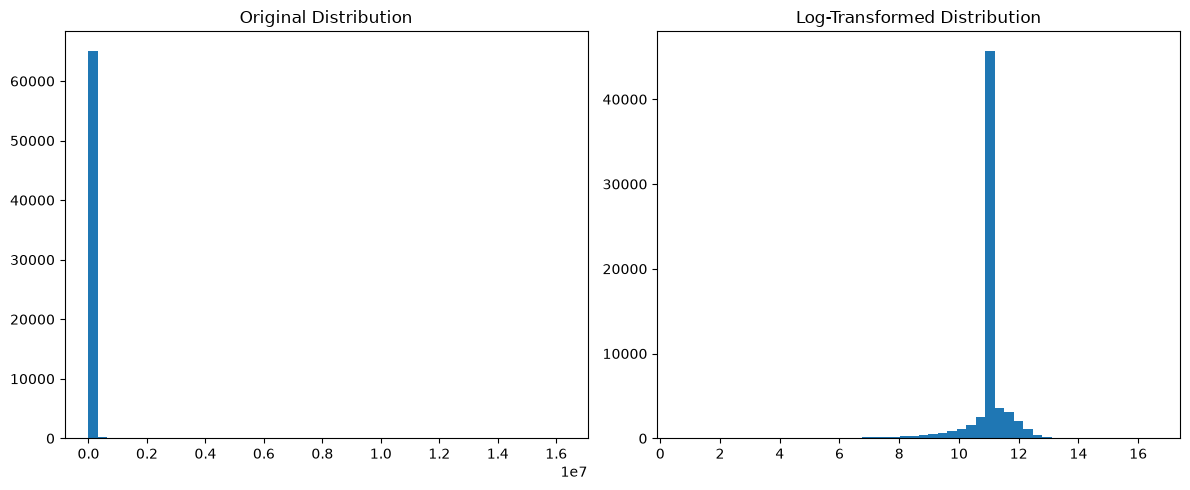

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(df['ConvertedCompYearly'], bins=50)
plt.title('Original Distribution')

plt.subplot(1, 2, 2)
plt.hist(df['ConvertedCompYearly_Log'], bins=50)
plt.title('Log-Transformed Distribution')

plt.tight_layout()
plt.show()

### 7. Feature Engineering


<h5>7.1 Create a new column `ExperienceLevel` based on the `YearsCodePro` column:</h5>


In [22]:
df['YearsCodePro'] = df['YearsCodePro'].replace({'Less than 1 year': 0,'More than 50 years': 51})
df['YearsCodePro'] = pd.to_numeric(df['YearsCodePro'], errors='coerce')

In [24]:
def experience_level(years):
    if pd.isna(years):
        return 'Unknown'
    elif years < 5:
        return 'Beginner'
    elif years < 10:
        return 'Intermediate'
    else:
        return 'Advanced'

df['ExperienceLevel'] = df['YearsCodePro'].apply(experience_level)

print(df[['YearsCodePro', 'ExperienceLevel']].head())
print(df['ExperienceLevel'].value_counts())

   YearsCodePro ExperienceLevel
0             2        Beginner
1            17        Advanced
2            27        Advanced
3             2        Beginner
4             2        Beginner
ExperienceLevel
Beginner        30798
Advanced        21711
Intermediate    12928
Name: count, dtype: int64

### Summary


In this lab, you:

- Explored the dataset to identify inconsistencies and missing values.

- Encoded categorical variables for analysis.

- Handled missing values using imputation techniques.

- Normalized and transformed numerical data to prepare it for analysis.

- Engineered a new feature to enhance data interpretation.


Copyright © IBM Corporation. All rights reserved.
